# 📊 H&M 이탈 분석 마스터 데이터셋 컬럼 상세 설명

### 1. 시간 및 이탈 정의 관련 (Time & Label)
* **`customer_id`**: 고객 식별 고유 해시값. 데이터 결합의 기준이 되는 Key 값입니다.
* **`first_buy` & `last_buy`**: 고객의 최초 및 최종 구매일. 고객의 전체 활동 기간을 파악하는 기초 자료입니다.
* **`tenure` (가입 기간)**: 최초 구매일부터 현재까지의 총 기간. 기간이 짧을수록 초기 이탈 위험이 높은 경향이 있습니다.
* **`recency` (최근성)**: 마지막 구매 후 경과일. 이탈 예측에서 가장 강력한 지표이며, 값이 클수록 이탈 가능성이 높습니다.
* **`threshold` (개별 기준일)**: 고객별 구매 패턴을 반영한 맞춤형 이탈 판단 기준일입니다.
* **`churn` (이탈 여부)**: **Target 변수**. 기준일(`threshold`)을 넘기면 1(이탈), 아니면 0(유지)으로 정의합니다.

### 2. 구매 행동 지표 (Behavioral RFM)
* **`frequency` (구매 횟수)**: 총 구매 횟수. 브랜드에 대한 충성도를 나타내며, 특정 횟수 이상 구매 시 이탈률이 급감하는 지표입니다.
* **`price_mean` (평균 구매액)**: 1회 쇼핑 시 평균 지출액. 고객의 소비 파워와 선호 가격대를 보여줍니다.
* **`price_sum` (총 매출액)**: 고객이 기여한 총 매출. 이탈 시 타격이 큰 고가치 고객(VVIP) 식별에 사용됩니다.

### 3. 마케팅 및 회원 상태 (Marketing & Status)
* **`FN` (패션 뉴스 수신)**: 뉴스레터 구독 여부. 브랜드 마케팅 메시지에 대한 고객의 개방도를 나타냅니다.
* **`Active` (활동 상태)**: 마케팅 활동의 활성화 여부. 고객의 적극적인 참여도를 측정합니다.
* **`club_member_status`**: 멤버십 등급(Active, Pre-create 등). 서비스에 대한 소속감과 가입 상태를 확인합니다.
* **`fashion_news_frequency`**: 뉴스레터 수신 빈도 설정값. 고객의 관심도나 마케팅 피로도를 짐작할 수 있습니다.

### 4. 고객 프로필 및 취향 (Profile & Style)
* **`age` (나이)**: 고객 연령. 연령별로 유행 민감도와 재구매 주기가 다르므로 필수적인 분석 변수입니다.
* **`index_group_name` (선호 카테고리)**: 가장 많이 구매한 대분류(Ladies, Mens 등). 고객의 성별 및 라이프스타일을 대변합니다.
* **`product_group_name` (주력 품목)**: 주력 구매 품목(Shoes, Upper 등). 품목별 재구매 주기 차이를 분석하는 데 유용합니다.

# Import libraries

In [7]:
# for data manipulation
import numpy as np
import pandas as pd

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for data splitting, transforming and model training
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Import Warnings
import warnings
warnings.simplefilter(action="ignore")

In [8]:
# Setting Configurations:

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [3]:
import pandas as pd

# 저장했던 데이터 불러오기
df = pd.read_csv('./data/hnm_churn_master_dataset.csv')

# 데이터 구조와 결측치 비율 확인
print(df.info())
print("\n--- 컬럼별 결측치 비율 ---")
print(df.isnull().mean() * 100)

<class 'pandas.DataFrame'>
RangeIndex: 1338029 entries, 0 to 1338028
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1338029 non-null  str    
 1   first_buy               1338029 non-null  str    
 2   last_buy                1338029 non-null  str    
 3   tenure                  1338029 non-null  int64  
 4   recency                 1338029 non-null  int64  
 5   threshold               1338029 non-null  int64  
 6   churn                   1338029 non-null  int64  
 7   frequency               1338029 non-null  int64  
 8   price_mean              1338029 non-null  float64
 9   price_sum               1338029 non-null  float64
 10  FN                      464994 non-null   float64
 11  Active                  452671 non-null   float64
 12  club_member_status      1332040 non-null  str    
 13  fashion_news_frequency  1322068 non-null  str    
 14  age          

In [9]:
df.head()

,customer_id,first_buy,last_buy,tenure,recency,threshold,churn,frequency,price_mean,price_sum,FN,Active,club_member_status,fashion_news_frequency,age,index_group_name,product_group_name
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,2018-12-27,2020-09-05,635,17,203,0,21,0.031,0.649,NaN,NaN,ACTIVE,NONE,49.000,Ladieswear,Garment Upper body
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2018-09-21,2020-07-08,732,76,203,0,86,0.030,2.602,NaN,NaN,ACTIVE,NONE,25.000,Ladieswear,Swimwear
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,2018-09-20,2020-09-15,733,7,203,0,18,0.039,0.705,NaN,NaN,ACTIVE,NONE,24.000,Ladieswear,Garment Upper body
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,2019-06-09,2019-06-09,471,471,203,1,2,0.030,0.061,NaN,NaN,ACTIVE,NONE,54.000,Sport,Underwear
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,2018-10-12,2020-08-12,711,41,203,0,13,0.036,0.470,1.000,1.000,ACTIVE,Regularly,52.000,Ladieswear,Garment Upper body


In [10]:
def check_data(dataframe, head=5):

    print(20*"-" + "Information".center(20) + 20*"-")
    print(dataframe.info())
    print(20*"-" + "Data Shape".center(20) + 20*"-")
    print(dataframe.shape)
    print("\n" + 20*"-" + "The First 5 Data".center(20) + 20*"-")
    print(dataframe.head())
    print("\n" + 20 * "-" + "The Last 5 Data".center(20) + 20 * "-")
    print(dataframe.tail())
    print("\n" + 20 * "-" + "Missing Values".center(20) + 20 * "-")
    print(dataframe.isnull().sum())
    print("\n" + 40 * "-" + "Describe the Data".center(40) + 40 * "-")
    print(dataframe.describe([0.01, 0.05, 0.10, 0.50, 0.75, 0.90, 0.95, 0.99]).T)


check_data(df)

--------------------    Information     --------------------
<class 'pandas.DataFrame'>
RangeIndex: 1338029 entries, 0 to 1338028
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1338029 non-null  str    
 1   first_buy               1338029 non-null  str    
 2   last_buy                1338029 non-null  str    
 3   tenure                  1338029 non-null  int64  
 4   recency                 1338029 non-null  int64  
 5   threshold               1338029 non-null  int64  
 6   churn                   1338029 non-null  int64  
 7   frequency               1338029 non-null  int64  
 8   price_mean              1338029 non-null  float64
 9   price_sum               1338029 non-null  float64
 10  FN                      464994 non-null   float64
 11  Active                  452671 non-null   float64
 12  club_member_status      1332040 non-null  str    
 13  fashion

In [11]:
# 1. 날짜 데이터 변환 (가장 먼저 수행)
df['first_buy'] = pd.to_datetime(df['first_buy'])
df['last_buy'] = pd.to_datetime(df['last_buy'])

# 2. 문자열 -> 카테고리 변환 (메모리 절감의 핵심)
cat_cols = ['club_member_status', 'fashion_news_frequency', 'index_group_name', 'product_group_name']
for col in cat_cols:
    df[col] = df[col].astype('category')

# 3. 정수형 타입 다운캐스팅
df['churn'] = df['churn'].astype('int8')
df['tenure'] = df['tenure'].astype('int32')
df['recency'] = df['recency'].astype('int32')
df['threshold'] = df['threshold'].astype('int32')
df['frequency'] = df['frequency'].astype('int32')

# 4. 실수형 타입 다운캐스팅 (결측치가 있는 age 포함)
df['age'] = df['age'].astype('float32')
df['price_mean'] = df['price_mean'].astype('float32')
df['price_sum'] = df['price_sum'].astype('float32')
df['FN'] = df['FN'].astype('float16')
df['Active'] = df['Active'].astype('float16')

# 5. 결과 확인
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338029 entries, 0 to 1338028
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   customer_id             1338029 non-null  str           
 1   first_buy               1338029 non-null  datetime64[us]
 2   last_buy                1338029 non-null  datetime64[us]
 3   tenure                  1338029 non-null  int32         
 4   recency                 1338029 non-null  int32         
 5   threshold               1338029 non-null  int32         
 6   churn                   1338029 non-null  int8          
 7   frequency               1338029 non-null  int32         
 8   price_mean              1338029 non-null  float32       
 9   price_sum               1338029 non-null  float32       
 10  FN                      464994 non-null   float16       
 11  Active                  452671 non-null   float16       
 12  club_member_status      1

In [13]:
# To find the number of churners and non-churners in the dataset:
df["churn"].value_counts()

churn
1    695391
0    642638
Name: count, dtype: int64

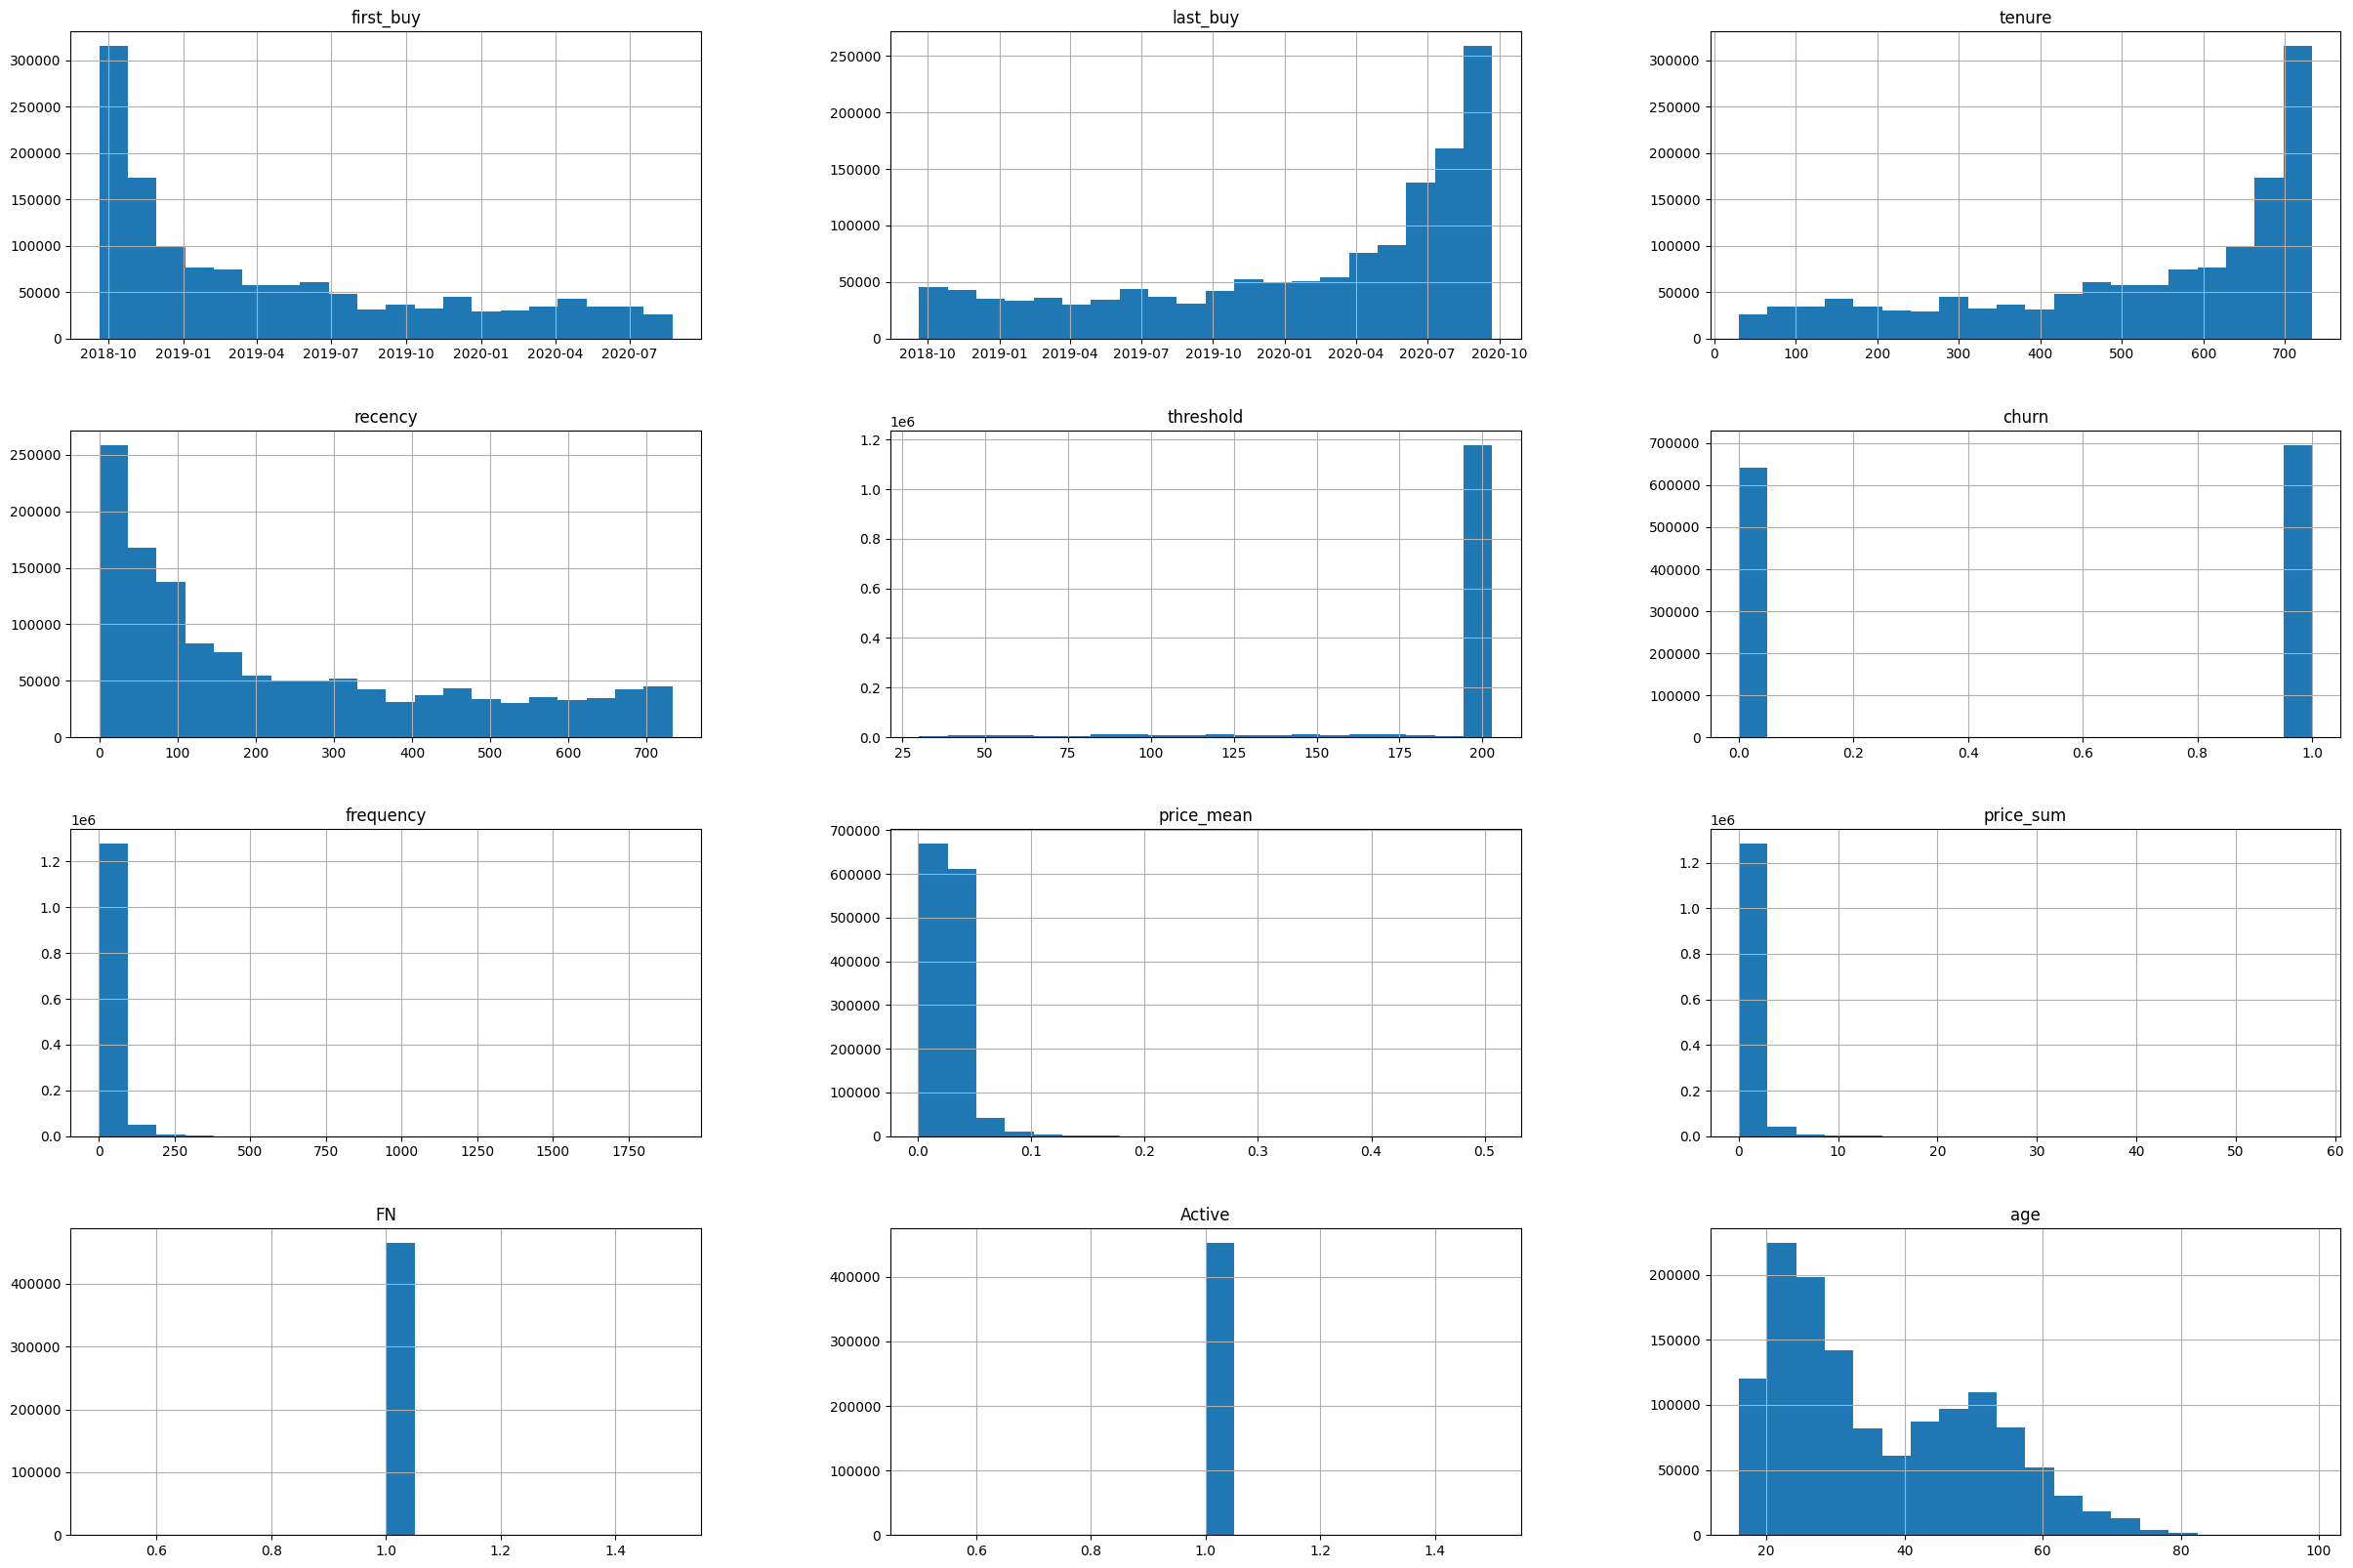

In [14]:
num_bins = 20
df.hist(bins=num_bins, figsize=(30,20))
plt.savefig("churn_histogram")
plt.show()

In [15]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
  
    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(df)

cat_cols
num_cols

Observations: 1338029
Variables: 17
cat_cols: 6
num_cols: 11
cat_but_car: 0
num_but_cat: 6


['customer_id',
 'first_buy',
 'last_buy',
 'tenure',
 'recency',
 'threshold',
 'frequency',
 'price_mean',
 'price_sum',
 'age',
 'product_group_name']

# Analyze the numerical and categorical variables

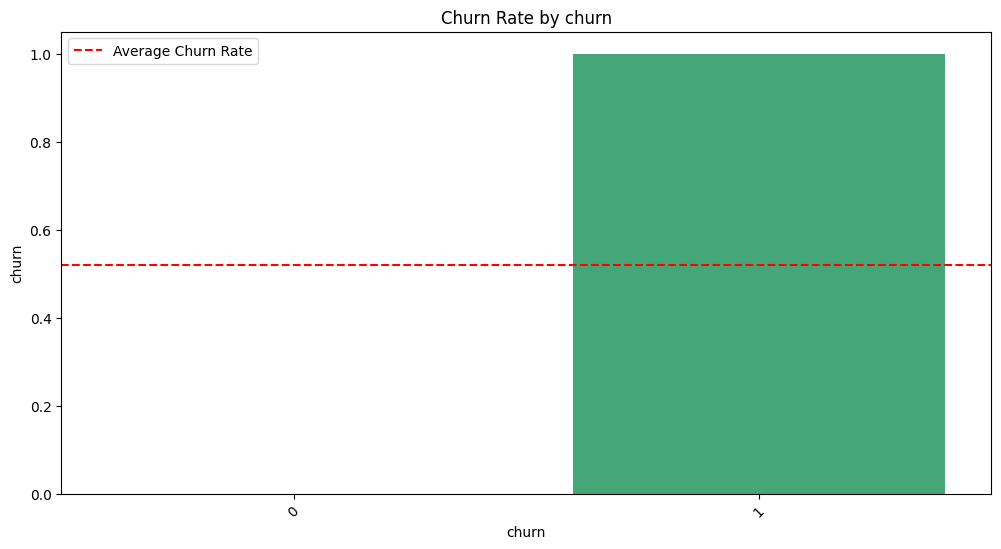

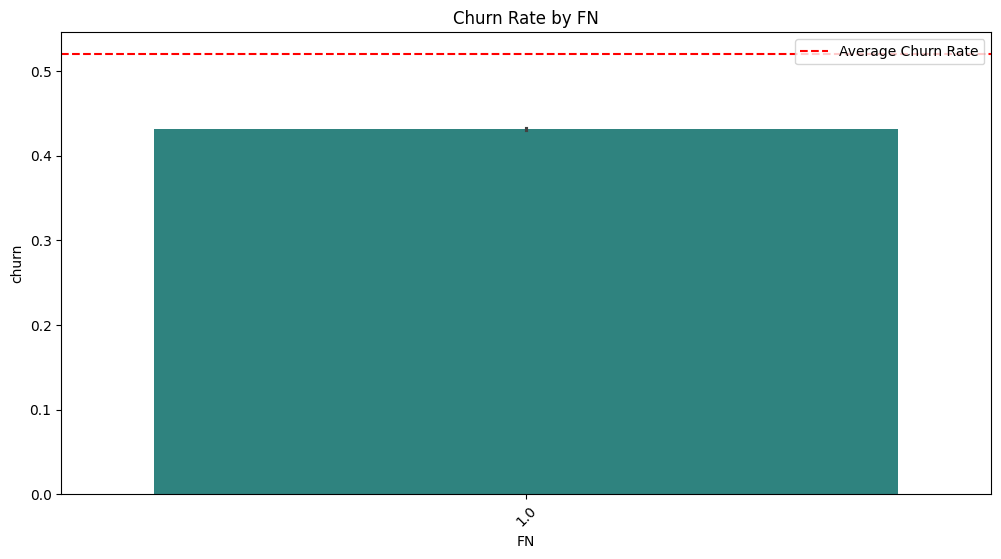

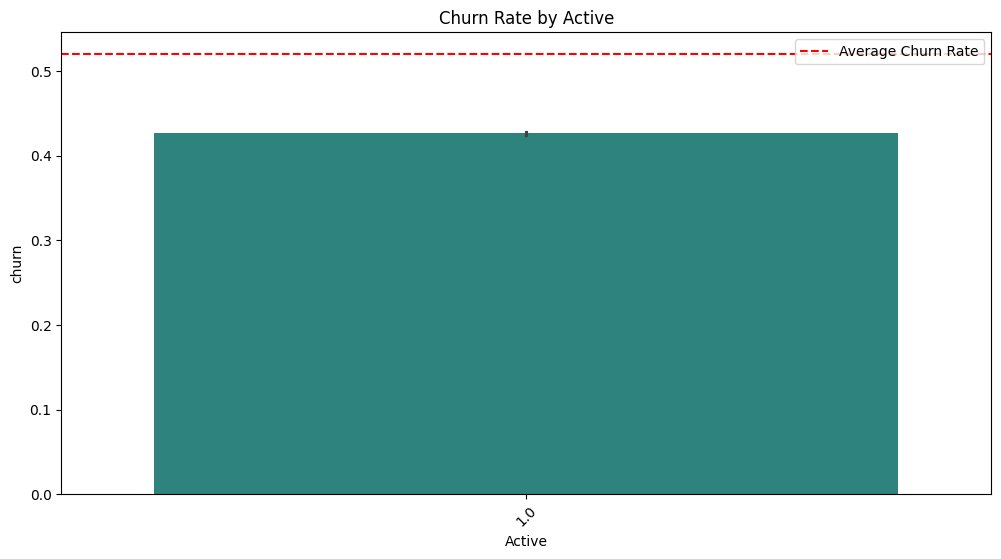

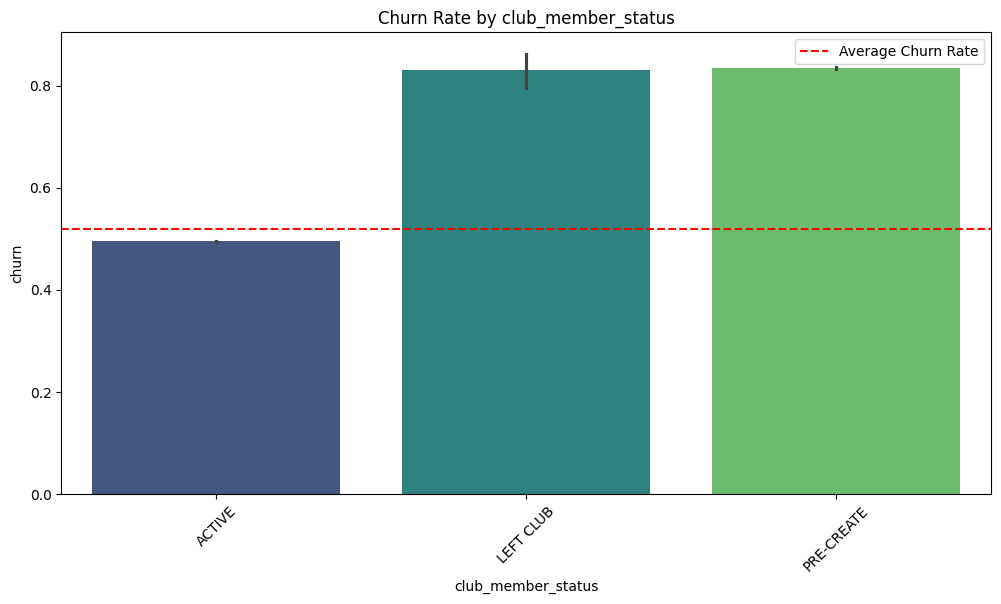

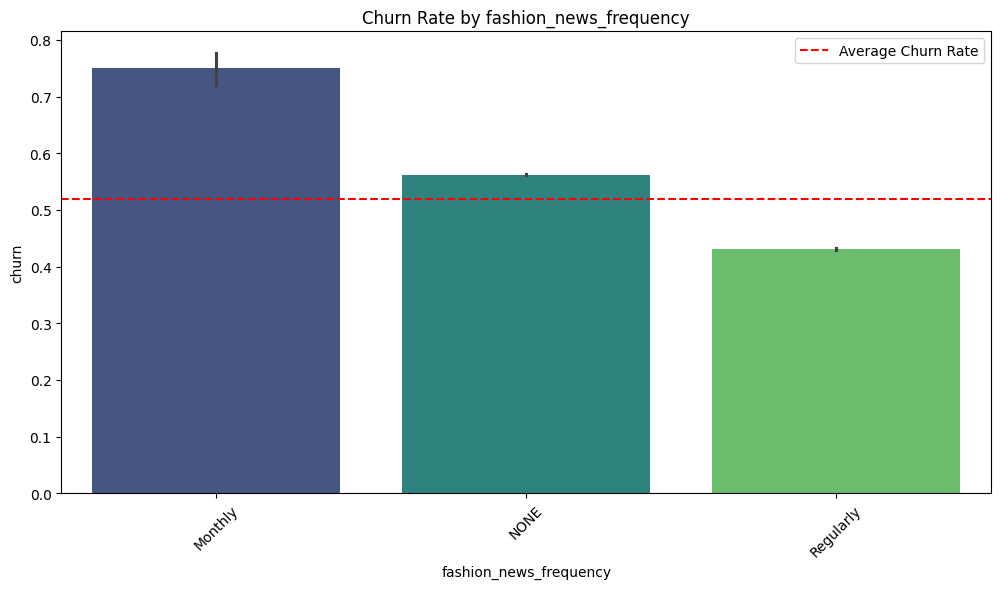

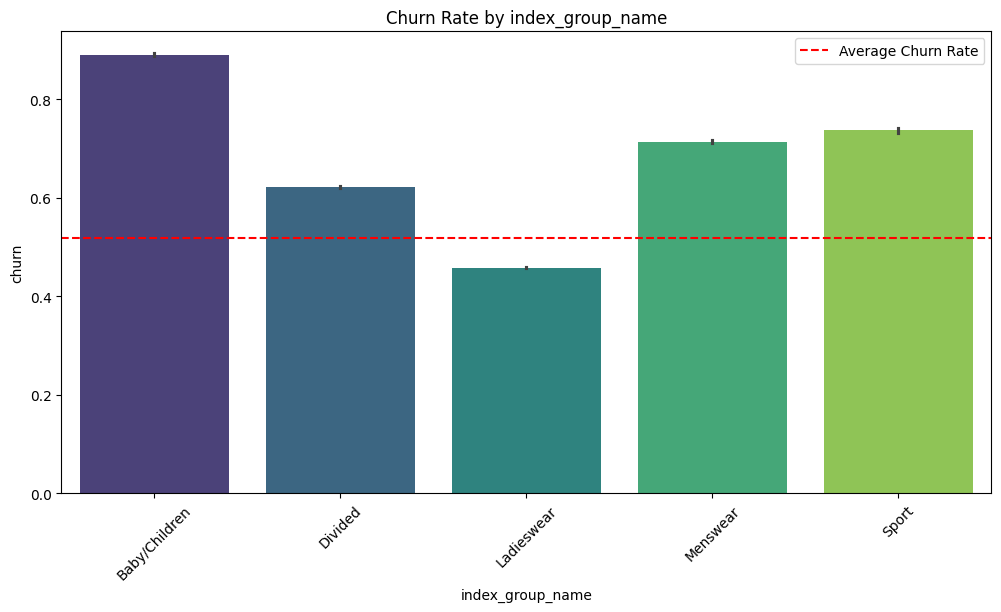

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def target_vs_category_visual(dataframe, target, categorical_col):
    plt.figure(figsize=(12, 6))
    
    # 1. float16 에러 방지를 위해 임시로 타입 변환 후 데이터 준비
    # 카테고리별 이탈률(mean)을 계산합니다.
    df_temp = dataframe.copy()
    if df_temp[categorical_col].dtype == 'float16':
        df_temp[categorical_col] = df_temp[categorical_col].astype('float32')
        
    # 2. 카테고리별 이탈률(평균) 시각화
    # Churn이 0, 1이므로 평균을 내면 곧 이탈률이 됩니다.
    sns.barplot(x=categorical_col, y=target, data=df_temp, palette='viridis')
    
    # 전체 평균 이탈률 선 표시 (기준점)
    plt.axhline(dataframe[target].mean(), color='red', linestyle='--', label='Average Churn Rate')
    
    plt.title(f"Churn Rate by {categorical_col}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

# 시각화 실행
# cat_cols에 FN, Active 등이 포함되어 있다면 이 코드가 에러 없이 돌아갑니다.
for col in cat_cols:
    target_vs_category_visual(df, "churn", col)

# Perform target variable analysis

In [20]:
# 1. 실제 숫자형 컬럼만 골라내기 (정수형, 실수형 포함)
# churn은 타겟이므로 제외하고, id나 날짜 컬럼도 제외됩니다.
num_cols = df.select_dtypes(include=['int32', 'int64', 'float32', 'float64', 'float16']).columns.tolist()

# 타겟 변수인 churn은 분석 대상에서 제외
if 'churn' in num_cols:
    num_cols.remove('churn')
if 'threshold' in num_cols: # threshold도 기준값이니 제외하는 게 깔끔합니다.
    num_cols.remove('threshold')

# 2. 요약 함수 (float16 연산 에러 방지를 위해 변환 추가)
def target_summary_with_num(dataframe, target, numerical_col):
    print(f"=== {numerical_col} by {target} ===")
    # float16은 mean 연산 시 에러가 날 수 있으므로 float32로 변환 후 계산
    temp_col = dataframe[numerical_col].astype('float32')
    print(dataframe.groupby(target)[numerical_col].mean(), end="\n\n")

# 3. 실행
for col in num_cols:
    target_summary_with_num(df, "churn", col)

=== tenure by churn ===
churn
0   557.237
1   480.757
Name: tenure, dtype: float64

=== recency by churn ===
churn
0    64.011
1   401.022
Name: recency, dtype: float64

=== frequency by churn ===
churn
0   40.929
1    7.765
Name: frequency, dtype: float64

=== price_mean by churn ===
churn
0   0.028
1   0.030
Name: price_mean, dtype: float32

=== price_sum by churn ===
churn
0   1.142
1   0.213
Name: price_sum, dtype: float32

=== FN by churn ===
churn
0   1.000
1   1.000
Name: FN, dtype: float16

=== Active by churn ===
churn
0   1.000
1   1.000
Name: Active, dtype: float16

=== age by churn ===
churn
0   35.372
1   37.421
Name: age, dtype: float32



In [23]:
# 1. 숫자형 컬럼 리스트 정의 (이전에 사용한 방식)
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# 타겟과 기준값은 제외
for col_to_remove in ['churn', 'threshold']:
    if col_to_remove in num_cols:
        num_cols.remove(col_to_remove)

# 2. 타입 에러를 방지한 요약 함수
def target_summary_with_num(dataframe, target, numerical_col):
    print(f"=== {numerical_col} by {target} ===")
    
    # [핵심] 연산 시에만 float32로 변환하여 Overflow와 NotImplementedError 방지
    result = dataframe.groupby(target)[numerical_col].apply(lambda x: x.astype('float32').mean())
    
    print(result, end="\n\n")

# 3. 분석 실행
for col in num_cols:
    target_summary_with_num(df, "churn", col)

=== tenure by churn ===
churn
0   557.237
1   480.757
Name: tenure, dtype: float32

=== recency by churn ===
churn
0    64.011
1   401.022
Name: recency, dtype: float32

=== frequency by churn ===
churn
0   40.929
1    7.765
Name: frequency, dtype: float32

=== price_mean by churn ===
churn
0   0.028
1   0.030
Name: price_mean, dtype: float32

=== price_sum by churn ===
churn
0   1.142
1   0.213
Name: price_sum, dtype: float32

=== FN by churn ===
churn
0   1.000
1   1.000
Name: FN, dtype: float32

=== Active by churn ===
churn
0   1.000
1   1.000
Name: Active, dtype: float32

=== age by churn ===
churn
0   35.372
1   37.421
Name: age, dtype: float32



# Perform outlier observation analysis.

In [25]:
# 1. 진짜 숫자형(정수, 실수) 컬럼만 정확히 추출
# datetime이나 object, category는 모두 제외됩니다.
num_cols = df.select_dtypes(include=['int32', 'int64', 'float32', 'float64', 'float16']).columns.tolist()

# 2. 분석에 의미 없는 타겟(churn)이나 기준값(threshold)은 리스트에서 제거
for col_to_remove in ['churn', 'threshold']:
    if col_to_remove in num_cols:
        num_cols.remove(col_to_remove)

# 3. 이상치 확인 함수 (그대로 사용하되 리스트만 바뀜)
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    # float16 에러 방지를 위해 계산 시에만 float32로 변환
    temp_series = dataframe[col_name].astype('float32')
    quartile1 = temp_series.quantile(q1)
    quartile3 = temp_series.quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    # 비교 연산 시 float32로 안전하게 진행
    if ((dataframe[col_name].astype('float32') > up_limit) | 
        (dataframe[col_name].astype('float32') < low_limit)).any():
        return True
    else:
        return False

# 4. 결과 출력
for col in num_cols:
    print(f"{col}: {check_outlier(df, col)}")

tenure: False
recency: False
frequency: True
price_mean: True
price_sum: True
FN: False
Active: False
age: False


# Perform a missing observation analysis.

In [26]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns


missing_values_table(df)

                        n_miss  ratio
Active                  885358 66.170
FN                      873035 65.250
fashion_news_frequency   15961  1.190
age                      15555  1.160
club_member_status        5989  0.450


In [27]:
# 1. 마케팅 관련 결측치는 0으로 (거부 의사로 간주)
df['FN'] = df['FN'].fillna(0)
df['Active'] = df['Active'].fillna(0)

# 2. 나이는 중앙값으로 채우기
df['age'] = df['age'].fillna(df['age'].median())

# 3. 범주형 변수의 결측치는 새로운 카테고리 'UNKNOWN'으로 통일
cat_fix_cols = ['club_member_status', 'fashion_news_frequency']
for col in cat_fix_cols:
    # 카테고리 타입에 'UNKNOWN' 추가 후 결측치 채우기
    if 'UNKNOWN' not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories(['UNKNOWN'])
    df[col] = df[col].fillna('UNKNOWN')

print("--- 결측치 처리 완료 ---")
print(df.isnull().sum())

--- 결측치 처리 완료 ---
customer_id               0
first_buy                 0
last_buy                  0
tenure                    0
recency                   0
threshold                 0
churn                     0
frequency                 0
price_mean                0
price_sum                 0
FN                        0
Active                    0
club_member_status        0
fashion_news_frequency    0
age                       0
index_group_name          0
product_group_name        0
dtype: int64


# Perform correlation analysis.

In [28]:
corr_matrix = df[num_cols].corr()
corr_matrix

,tenure,recency,frequency,price_mean,price_sum,FN,Active,age
tenure,1.000,0.202,0.340,-0.019,0.316,0.092,0.089,0.071
recency,0.202,1.000,-0.372,0.075,-0.342,-0.105,-0.116,0.094
frequency,0.340,-0.372,1.000,-0.036,0.959,0.101,0.105,-0.015
price_mean,-0.019,0.075,-0.036,1.000,0.069,-0.039,-0.038,0.122
price_sum,0.316,-0.342,0.959,0.069,1.000,0.087,0.091,0.005
FN,0.092,-0.105,0.101,-0.039,0.087,1.000,0.980,0.035
Active,0.089,-0.116,0.105,-0.038,0.091,0.980,1.000,0.038
age,0.071,0.094,-0.015,0.122,0.005,0.035,0.038,1.000


In [30]:
# 1. 숫자형 데이터만 있는 데이터프레임 따로 만들기
# churn을 포함한 숫자형 컬럼만 필터링합니다.
numeric_df = df.select_dtypes(include=['number'])

# 2. 상관계수 구하기
# 이제 문자열 ID나 날짜 데이터가 빠졌으므로 에러 없이 돌아갑니다.
churn_corr = numeric_df.corr()['churn'].sort_values(ascending=False)

print("--- Churn과의 상관계수 순위 ---")
print(churn_corr)

--- Churn과의 상관계수 순위 ---
churn         1.000
recency       0.762
price_mean    0.078
age           0.069
threshold    -0.099
FN           -0.128
Active       -0.134
tenure       -0.186
price_sum    -0.385
frequency    -0.419
Name: churn, dtype: float64


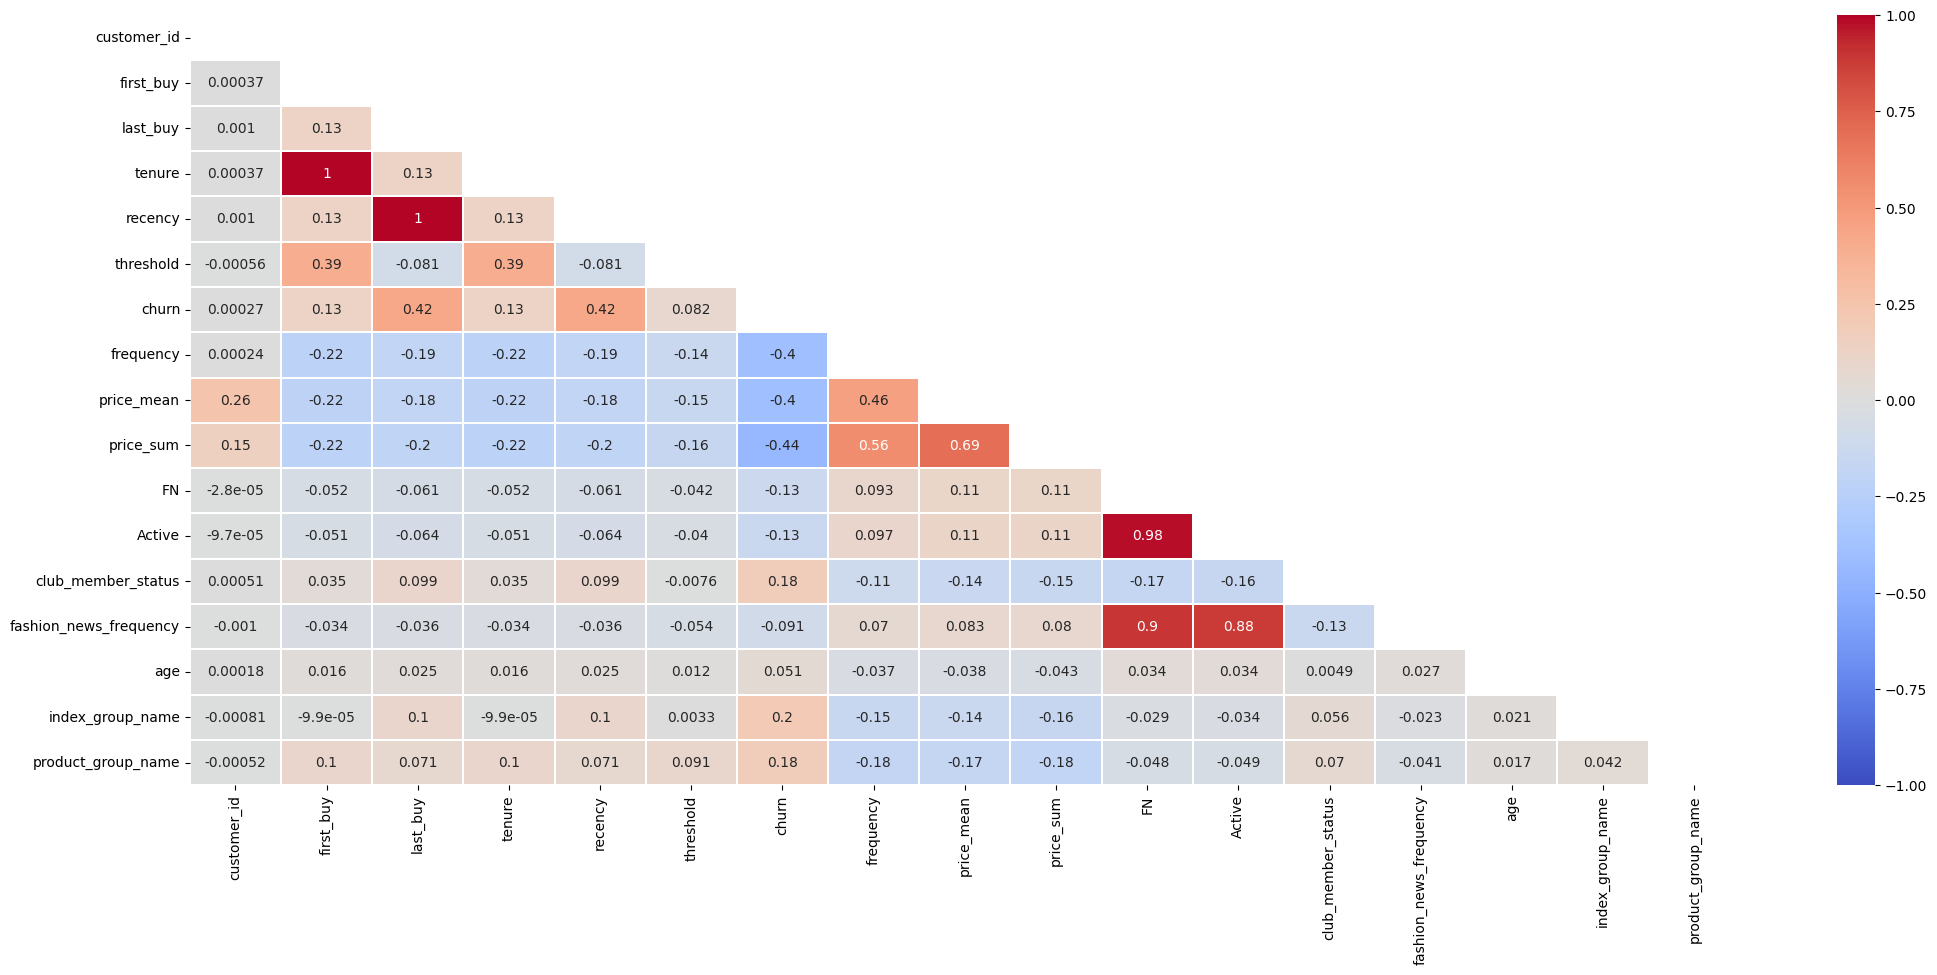

In [31]:
# Correlation between all variables
plt.figure(5, figsize=(25, 10))
corr = df.apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

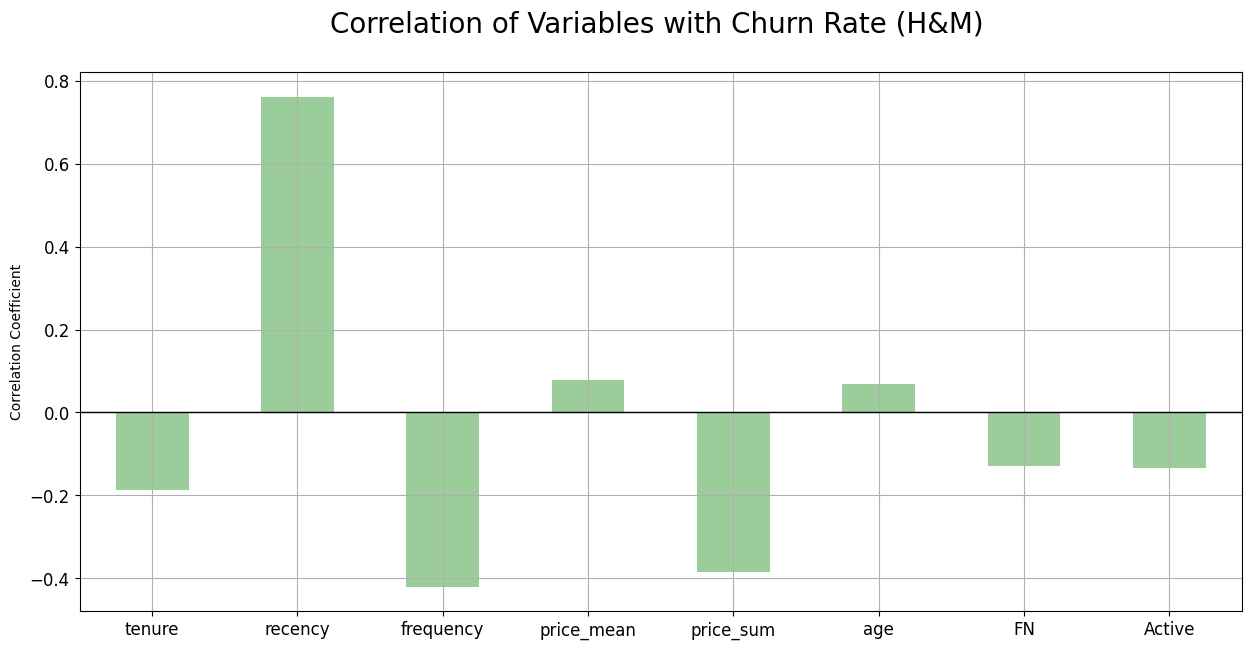

In [34]:
import matplotlib.pyplot as plt

# 1. 시각화할 수치형 변수들 선택 (H&M 데이터셋 전용)
# 분석 목적에 맞는 핵심 변수들만 추렸습니다.
ds_corr = df[['tenure', 'recency', 'frequency', 'price_mean', 'price_sum', 'age', 'FN', 'Active']]

# 2. Churn과의 상관계수 계산
correlations = ds_corr.corrwith(df.churn)

# 3. 시각화 설정
plt.figure(figsize=(15, 8))
correlations.plot.bar(
    figsize = (15, 7),
    fontsize = 12,
    color = '#9BCD9B', # 부드러운 녹색 계열
    rot = 0,           # 가독성을 위해 글자를 똑바로 세움
    grid = True
)

# 차트 디자인 개선
plt.title('Correlation of Variables with Churn Rate (H&M) \n', 
          horizontalalignment="center", fontstyle = "normal", 
          fontsize = "20", fontfamily = "sans-serif")
plt.axhline(0, color='black', linewidth=1) # 기준선 추가
plt.ylabel('Correlation Coefficient')
plt.show()


📑 Analysis: Correlation with Churn Rate
By looking at the correlation results, we can make the following comments:

1. Recency as the Primary Predictor (Positive Correlation)
Comment: recency shows the strongest positive correlation with the churn rate.

Insight: 마지막 구매 이후 경과일이 길어질수록 이탈 가능성이 기하급수적으로 높아집니다. 이는 님이 설계한 이탈 정의가 데이터의 실제 흐름을 매우 강력하게 반영하고 있음을 시사합니다. 이탈 징후를 포착하는 가장 즉각적인 'Red Flag' 지표입니다.

2. Loyalty Metrics as Defensive Barriers (Negative Correlation)
Comment: frequency, price_sum, and tenure exhibit significant negative correlations with churn.

Insight: 구매 횟수가 많고, 총 지출액이 크며, 가입 기간이 길수록 이탈률은 낮아집니다. 특히 frequency가 높을수록 고객은 브랜드에 대한 관성이 생기며, 이는 이탈을 막는 심리적·행동적 방어막 역할을 합니다.

3. The Power of Marketing Engagement
Comment: FN (Fashion News) and Active status are negatively correlated with churn, though the magnitude is lower than behavioral metrics.

Insight: 마케팅 메시지를 수신하고 활동 상태가 활성화된 고객일수록 이탈 확률이 낮습니다. 브랜드와의 지속적인 소통 채널을 열어두는 것이 고객 유지(Retention)에 긍정적인 영향을 미치고 있음을 보여줍니다.

4. Low Impact of Demographic & Unit Price Factors
Comment: age and price_mean show near-zero or very weak correlations with the churn label.

Insight: 나이나 건당 평균 구매 금액은 고객이 떠날지 말지를 결정하는 결정적인 요인이 아닙니다. 즉, "부유한 고객(High price_mean)이나 특정 연령층이 더 충성도가 높다"는 가설은 본 데이터셋에서 성립하지 않으며, 이탈 방지 전략은 인구통계학적 접근보다 행동 기반(Behavior-based) 접근이 훨씬 효과적임을 의미합니다.

# Perform the encoding operations.

In [36]:
le = LabelEncoder()

binary_cols = [col for col in df.columns if df[col].dtype not in [int, float]
               and df[col].nunique() == 2]

def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

for col in binary_cols:
    df = label_encoder(df, col)

def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

ohe_cols = [col for col in df.columns if 30 >= df[col].nunique() > 2]

df = one_hot_encoder(df, ohe_cols)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338029 entries, 0 to 1338028
Data columns (total 40 columns):
 #   Column                                    Non-Null Count    Dtype         
---  ------                                    --------------    -----         
 0   customer_id                               1338029 non-null  str           
 1   first_buy                                 1338029 non-null  datetime64[us]
 2   last_buy                                  1338029 non-null  datetime64[us]
 3   tenure                                    1338029 non-null  int32         
 4   recency                                   1338029 non-null  int32         
 5   threshold                                 1338029 non-null  int32         
 6   churn                                     1338029 non-null  int64         
 7   frequency                                 1338029 non-null  int32         
 8   price_mean                                1338029 non-null  float32       
 9   price_sum    

# Standardize for numeric variables.

In [38]:
num_cols = [col for col in num_cols if col not in "customerID"]
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].head()

,tenure,recency,frequency,price_mean,price_sum,FN,Active,age
0,0.571,-1.005,-0.068,0.159,-0.008,-0.730,-0.715,0.888
1,1.043,-0.738,1.577,0.113,1.611,-0.730,-0.715,-0.801
2,1.048,-1.050,-0.144,0.742,0.038,-0.730,-0.715,-0.871
3,-0.226,1.049,-0.549,0.130,-0.496,-0.730,-0.715,1.240
4,0.941,-0.896,-0.271,0.529,-0.157,1.370,1.399,1.099


In [39]:
df.head()

,customer_id,first_buy,last_buy,tenure,recency,threshold,churn,frequency,price_mean,price_sum,FN,Active,age,club_member_status_LEFT CLUB,club_member_status_PRE-CREATE,club_member_status_UNKNOWN,fashion_news_frequency_NONE,fashion_news_frequency_Regularly,fashion_news_frequency_UNKNOWN,index_group_name_Divided,index_group_name_Ladieswear,index_group_name_Menswear,index_group_name_Sport,product_group_name_Bags,product_group_name_Cosmetic,product_group_name_Furniture,product_group_name_Garment Full body,product_group_name_Garment Lower body,product_group_name_Garment Upper body,product_group_name_Garment and Shoe care,product_group_name_Interior textile,product_group_name_Items,product_group_name_Nightwear,product_group_name_Shoes,product_group_name_Socks & Tights,product_group_name_Stationery,product_group_name_Swimwear,product_group_name_Underwear,product_group_name_Underwear/nightwear,product_group_name_Unknown
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,2018-12-27,2020-09-05,0.571,-1.005,203,0,-0.068,0.159,-0.008,-0.730,-0.715,0.888,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2018-09-21,2020-07-08,1.043,-0.738,203,0,1.577,0.113,1.611,-0.730,-0.715,-0.801,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,2018-09-20,2020-09-15,1.048,-1.050,203,0,-0.144,0.742,0.038,-0.730,-0.715,-0.871,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,2019-06-09,2019-06-09,-0.226,1.049,203,1,-0.549,0.130,-0.496,-0.730,-0.715,1.240,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,2018-10-12,2020-08-12,0.941,-0.896,203,0,-0.271,0.529,-0.157,1.370,1.399,1.099,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False


# Build a model.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. 학습에 사용할 피처(X)와 정답(y) 정의
# customer_id(str), first_buy(datetime), last_buy(datetime)를 확실히 드롭합니다.
X = df.drop(columns=['customer_id', 'first_buy', 'last_buy', 'churn'])
y = df['churn']

# 2. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=17)

# 3. 모델 학습 (133만 건이므로 n_jobs=-1을 추가해 병렬 처리를 권장합니다)
rf_model = RandomForestClassifier(random_state=46, n_estimators=100, max_depth=10, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. 결과 확인
y_pred = rf_model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")

Accuracy Score: 0.9807702368407285


              precision    recall  f1-score   support

           0       0.98      0.98      0.98    128505
           1       0.98      0.99      0.98    139101

    accuracy                           0.98    267606
   macro avg       0.98      0.98      0.98    267606
weighted avg       0.98      0.98      0.98    267606



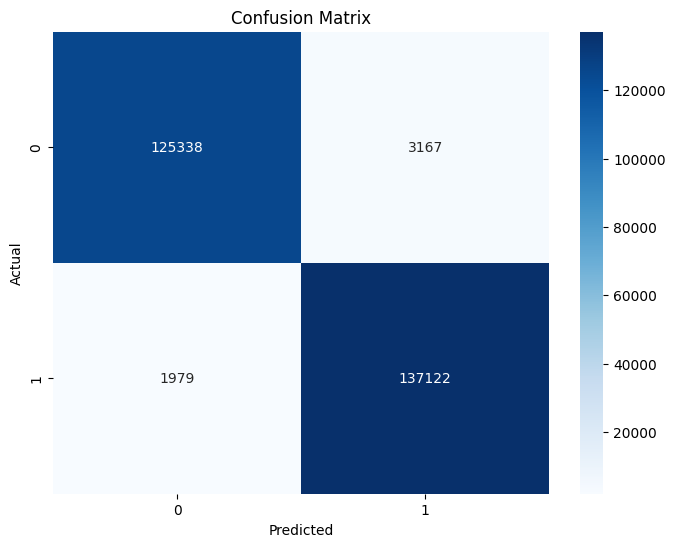

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. 상세 리포트 출력 (Precision, Recall, F1-score)
print(classification_report(y_test, y_pred))

# 2. 혼동 행렬(Confusion Matrix) 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [44]:
# 어떤 변수가 98%를 만들었는지 확인하기
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print("--- Top 5 Important Features ---")
print(importances.sort_values(ascending=False).head(5))

--- Top 5 Important Features ---
recency     0.587
frequency   0.171
price_sum   0.126
tenure      0.046
threshold   0.031
dtype: float64


In [45]:
# 1. recency까지 포함해서 제외할 컬럼 리스트 정의
# threshold도 recency와 계산적으로 묶여 있을 수 있으니 함께 제외해보는 것을 추천합니다.
drop_cols_new = ['customer_id', 'first_buy', 'last_buy', 'churn', 'recency', 'threshold']
X_no_recency = df.drop(columns=drop_cols_new)
y = df['churn']

# 2. 데이터 분할
X_train_nr, X_test_nr, y_train_nr, y_test_nr = train_test_split(X_no_recency, y, test_size=0.20, random_state=17)

# 3. 모델 학습 (동일한 조건)
rf_model_nr = RandomForestClassifier(random_state=46, n_estimators=100, max_depth=10, n_jobs=-1)
rf_model_nr.fit(X_train_nr, y_train_nr)

# 4. 결과 확인
y_pred_nr = rf_model_nr.predict(X_test_nr)
from sklearn.metrics import classification_report, accuracy_score
print(f"Accuracy Score (Without Recency): {accuracy_score(y_test_nr, y_pred_nr)}")
print(classification_report(y_test_nr, y_pred_nr))

Accuracy Score (Without Recency): 0.8065252647549008
              precision    recall  f1-score   support

           0       0.79      0.81      0.80    128505
           1       0.82      0.80      0.81    139101

    accuracy                           0.81    267606
   macro avg       0.81      0.81      0.81    267606
weighted avg       0.81      0.81      0.81    267606



In [46]:
importances_nr = pd.Series(rf_model_nr.feature_importances_, index=X_no_recency.columns)
print("--- New Top 5 Important Features (Without Recency) ---")
print(importances_nr.sort_values(ascending=False).head(5))

--- New Top 5 Important Features (Without Recency) ---
frequency                     0.454
price_sum                     0.367
tenure                        0.041
price_mean                    0.036
index_group_name_Ladieswear   0.028
dtype: float64
